<a href="https://colab.research.google.com/github/The-Professor99/ML_Practice/blob/main/hands_on_learning/tinkerings/001_Time_Series_Stores_Sales_Forecasting_EDA0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot

In [ ]:
%matplotlib
%matplotlib

Using matplotlib backend: <object object at 0x0000018053C349B0>
Using matplotlib backend: TkAgg


train.csv
The training data, comprising time series of features store_nbr, family, and onpromotion as well as the target sales.
store_nbr identifies the store(store number) at which the products are sold.
family identifies the type of product sold.
sales gives the total sales for a product family at a particular store at a given date. Fractional values are possible since products can be sold in fractional units (1.5 kg of cheese, for instance, as opposed to 1 bag of chips).
onpromotion gives the total number of items in a product family that were being promoted at a store at a given date.

stores.csv
Store metadata, including city, state, type, and cluster.
cluster is a grouping of similar stores.

oil.csv
Daily oil price. Includes values during both the train and test data timeframes. (Ecuador is an oil-dependent country and it's economical health is highly vulnerable to shocks in oil prices.)

holidays_events.csv
Holidays and Events, with metadata
NOTE: Pay special attention to the transferred column. A holiday that is transferred officially falls on that calendar day, but was moved to another date by the government. A transferred day is more like a normal day than a holiday. To find the day that it was actually celebrated, look for the corresponding row where type is Transfer. For example, the holiday Independencia de Guayaquil was transferred from 2012-10-09 to 2012-10-12, which means it was celebrated on 2012-10-12. Days that are type Bridge are extra days that are added to a holiday (e.g., to extend the break across a long weekend). These are frequently made up by the type Work Day which is a day not normally scheduled for work (e.g., Saturday) that is meant to payback the Bridge.
Additional holidays are days added a regular calendar holiday, for example, as typically happens around Christmas (making Christmas Eve a holiday).

transactions.csv
number of transactions performed at each store per day

Additional Notes
Wages in the public sector are paid every two weeks on the 15 th and on the last day of the month. Supermarket sales could be affected by this.
A magnitude 7.8 earthquake struck Ecuador on April 16, 2016. People rallied in relief efforts donating water and other first need products which greatly affected supermarket sales for several weeks after the earthquake.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# From Lesson 3
def seasonal_plot(X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette(
        "husl",
        n_colors=X[period].nunique(),
    )
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        errorbar=('ci', False),
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )
    return ax


def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax


# From Lesson 4
def lagplot(x, y=None, shift=1, standardize=False, ax=None, **kwargs):
    from matplotlib.offsetbox import AnchoredText
    x_ = x.shift(shift)
    if standardize:
        x_ = (x_ - x_.mean()) / x_.std()
    if y is not None:
        y_ = (y - y.mean()) / y.std() if standardize else y
    else:
        y_ = x
    corr = y_.corr(x_)
    if ax is None:
        fig, ax = plt.subplots()
    scatter_kws = dict(
        alpha=0.75,
        s=3,
    )
    line_kws = dict(color='C3', )
    ax = sns.regplot(x=x_,
                     y=y_,
                     scatter_kws=scatter_kws,
                     line_kws=line_kws,
                     lowess=True,
                     ax=ax,
                     **kwargs)
    at = AnchoredText(
        f"{corr:.2f}",
        prop=dict(size="large"),
        frameon=True,
        loc="upper left",
    )
    at.patch.set_boxstyle("square, pad=0.0")
    ax.add_artist(at)
    title = f"Lag {shift}" if shift > 0 else f"Lead {shift}"
    ax.set(title=f"Lag {shift}", xlabel=x_.name, ylabel=y_.name)
    return ax


def plot_lags(x,
              y=None,
              lags=6,
              leads=None,
              nrows=1,
              lagplot_kwargs={},
              **kwargs):
    import math
    kwargs.setdefault('nrows', nrows)
    orig = leads is not None
    leads = leads or 0
    kwargs.setdefault('ncols', math.ceil((lags + orig + leads) / nrows))
    kwargs.setdefault('figsize', (kwargs['ncols'] * 2, nrows * 2 + 0.5))
    fig, axs = plt.subplots(sharex=True, sharey=True, squeeze=False, **kwargs)
    for ax, k in zip(fig.get_axes(), range(kwargs['nrows'] * kwargs['ncols'])):
        k -= leads + orig
        if k + 1 <= lags:
            ax = lagplot(x, y, shift=k + 1, ax=ax, **lagplot_kwargs)
            title = f"Lag {k + 1}" if k + 1 >= 0 else f"Lead {-k - 1}"
            ax.set_title(title, fontdict=dict(fontsize=14))
            ax.set(xlabel="", ylabel="")
        else:
            ax.axis('off')
    plt.setp(axs[-1, :], xlabel=x.name)
    plt.setp(axs[:, 0], ylabel=y.name if y is not None else x.name)
    fig.tight_layout(w_pad=0.1, h_pad=0.1)
    return fig


# def make_lag_features(y, lags):
#     name = 'lag' if lags > 0 else 'lead'
#     steps = range(1, lags + 1) if lags > 0 else range(-1, lags - 1, -1)
#     return pd.concat(
#         [y.shift(i, freq='infer') for i in steps],
#         axis=1,
#         join='outer',
#         keys=[f'{y.name}_{name}_{i if lags > 0 else -i}' for i in steps],
#     )

# From Lesson 5


class BoostedHybrid:
    def __init__(self, model_1, model_2):
        self.model_1 = model_1
        self.model_2 = model_2
        self.y_columns = None
        self.stack_cols = None

    def fit(self, X_1, X_2, y, stack_cols=None):
        # Train model_1
        self.model_1.fit(X_1, y)

        # Make predictions
        y_fit = pd.DataFrame(
            self.model_1.predict(X_1),
            index=X_1.index,
            columns=y.columns,
        )
        # Compute residuals
        y_resid = y - y_fit
        y_resid = y_resid.stack(stack_cols).squeeze()  # wide to long

        # Train model_2 on residuals
        self.model_2.fit(X_2, y_resid)

        # Save column names for predict method
        self.y_columns = y.columns
        self.stack_cols = stack_cols

    def predict(self, X_1, X_2):
        # Predict with model_1
        y_pred = pd.DataFrame(
            self.model_1.predict(X_1),
            index=X_1.index,
            columns=self.y_columns,
        )
        y_pred = y_pred.stack(self.stack_cols).squeeze()  # wide to long

        # Add model_2 predictions to model_1 predictions
        y_pred += self.model_2.predict(X_2)
        return y_pred.unstack(self.stack_cols)


# From Lesson 6
def make_lags(ts, lags, lead_time=1, name='y'):
    return pd.concat(
        {
            f'{name}_lag_{i}': ts.shift(i)
            for i in range(lead_time, lags + lead_time)
        },
        axis=1)


def make_leads(ts, leads, name='y'):
    return pd.concat(
        {f'{name}_lead_{i}': ts.shift(-i)
         for i in reversed(range(leads))},
        axis=1)


def make_multistep_target(ts, steps, reverse=False):
    shifts = reversed(range(steps)) if reverse else range(steps)
    return pd.concat({f'y_step_{i + 1}': ts.shift(-i) for i in shifts}, axis=1)


def create_multistep_example(n, steps, lags, lead_time=1):
    ts = pd.Series(
        np.arange(n),
        index=pd.period_range(start='2010', freq='A', periods=n, name='Year'),
        dtype=pd.Int8Dtype,
    )
    X = make_lags(ts, lags, lead_time)
    y = make_multistep_target(ts, steps, reverse=True)
    data = pd.concat({'Targets': y, 'Features': X}, axis=1)
    data = data.style.set_properties(['Targets'], **{'background-color': 'LavenderBlush'}) \
                     .set_properties(['Features'], **{'background-color': 'Lavender'})
    return data


def load_multistep_data():
    df1 = create_multistep_example(10, steps=1, lags=3, lead_time=1)
    df2 = create_multistep_example(10, steps=3, lags=4, lead_time=2)
    df3 = create_multistep_example(10, steps=3, lags=4, lead_time=1)
    return [df1, df2, df3]


def plot_multistep(y, every=1, ax=None, palette_kwargs=None):
    palette_kwargs_ = dict(palette='husl', n_colors=16, desat=None)
    if palette_kwargs is not None:
        palette_kwargs_.update(palette_kwargs)
    palette = sns.color_palette(**palette_kwargs_)
    if ax is None:
        fig, ax = plt.subplots()
    ax.set_prop_cycle(plt.cycler('color', palette))
    for date, preds in y[::every].iterrows():
        preds.index = pd.period_range(start=date, periods=len(preds))
        preds.plot(ax=ax)
    return ax

In [ ]:
plot_multistep(train_dataset[["sales"]], every=1782)

C:\Users\USER\Documents\ML\ml_env\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1399: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


<Axes: >

In [ ]:
def get_dataset(file_name):
    file_path = os.path.join("Datasets", "stores_sales", file_name)
    dtype = {
        'store_nbr': 'category',
        'family': 'category',
        'sales': 'float32',
        'onpromotion': 'uint64',
    }
    dataset = pd.read_csv(file_path, dtype=dtype, parse_dates=["date"])
#     if "date" in dataset.columns:
#         dataset.index = dataset["date"]
#         return dataset.drop(columns=["date"])
#     else:
    return dataset

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
dataset = get_dataset("train.csv")

In [ ]:
train_dataset, validation_dataset = train_test_split(dataset, shuffle=False)

In [ ]:
# train_dataset.to_csv("Datasets/stores_sales/train_dataset.csv", index=False)
# validation_dataset.to_csv("Datasets/stores_sales/val_dataset.csv", index=False)

In [ ]:
# train_dataset

In [ ]:
# validation_dataset

### Prepare Datasets

In [ ]:
# def prepare_dataset(dataset):
#     dataset["date"] = pd.to_datetime(dataset["date"])
#     dataset = dataset.set_index('date').to_period('D')
#     return dataset

In [ ]:
# train_dataset = prepare_dataset(train_dataset)
# X_train = train_dataset.drop(columns=["sales"])
# y_train = train_dataset["sales"]
# average_sales = y_train.groupby("date").mean()

### Add lags

In [ ]:
stores_count = len(dataset["store_nbr"].value_counts())
family_count = len(dataset["family"].value_counts())
categories_count = stores_count * family_count

In [ ]:
lag = 1

In [ ]:
train_dataset["sales_shifted"] = train_dataset["sales"].shift(categories_count * lag)

In [ ]:
sample_y = train_dataset[(train_dataset["family"] == "AUTOMOTIVE") & (train_dataset["store_nbr"] == "34")]["sales"]

In [ ]:
x = sample_y.rolling(window=30, center=True).mean()

In [ ]:
pd.DataFrame({"y": sample_y, "r_mean": x, }).plot()

<Axes: >

In [ ]:
from statsmodels.tsa.deterministic import DeterministicProcess

In [ ]:
dp = DeterministicProcess(sample_y.index, order=3)

In [ ]:
dp.in_sample()

,trend,trend_squared,trend_cubed
891,1.0,1.0,1.000000e+00
2673,2.0,4.0,8.000000e+00
4455,3.0,9.0,2.700000e+01
6237,4.0,16.0,6.400000e+01
8019,5.0,25.0,1.250000e+02
...,...,...,...
2242647,1259.0,1585081.0,1.995617e+09
2244429,1260.0,1587600.0,2.000376e+09
2246211,1261.0,1590121.0,2.005143e+09
2247993,1262.0,1592644.0,2.009917e+09


In [ ]:
sample_y.plot()

<Axes: xlabel='date'>

We could imagine learning the components of a time series as an iterative process: first learn the trend and subtract it out from the series, then learn the seasonality from the detrended residuals and subtract the seasons out, then learn the cycles and subtract the cycles out, and finally only the unpredictable error remains.



### Tests

In [ ]:
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from sklearn.linear_model import LinearRegression

In [ ]:
holidays_events = pd.read_csv(
    "Datasets/stores_sales/holidays_events.csv",
    dtype={
        "type": "category",
        "locale": "category",
        "locale_name": "category",
        "description": "category",
        "transferred": "bool"
    },
    parse_dates=["date"]
)
holidays_events = holidays_events.set_index("date").to_period("D")
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)

In [ ]:
stores_sales = pd.read_csv(
    "Datasets/stores_sales/train.csv",
    usecols=["store_nbr", "family", "date", "sales"],
    dtype={
        "store_nbr": "category",
        "family": "category",
        "sales": "float32"
    },
    parse_dates=["date"]
)
stores_sales["date"] = stores_sales.date.dt.to_period("D")
stores_sales = stores_sales.set_index(["store_nbr", "family", "date"]).sort_index()
average_sales = (stores_sales.groupby("date").mean().squeeze().loc["2017"])

### Determine Seasonality

In [ ]:
X_average = average_sales.to_frame()

In [ ]:
X_average["week"] = X_average.index.week
X_average["day"] = X_average.index.dayofweek
X_average["month"] = X_average.index.month
X_average["year"] = X_average.index.year

In [ ]:
# seasonal_plot(X_average, y="sales", period="year", freq="month" )

In [ ]:
# plot_periodogram(average_sales)

In [ ]:
fourier = CalendarFourier(freq="M", order=4)
dp = DeterministicProcess(
    index=average_sales.index,
    constant=True,
    order=1,
    seasonal=True,
    additional_terms=[fourier],
    drop=True
)
X = dp.in_sample()

In [ ]:
model = LinearRegression().fit(X, average_sales)
y_pred = pd.Series(
    model.predict(X),
    index=X.index,
    name="Fitted"
)

In [ ]:
def plot_y_over_pred(y, y_pred):
    ax = y.plot(**plot_params,
    alpha=0.5, title="Average Sales", ylabel="items sold")
    ax = y_pred.plot(ax=ax, label="Seasonal")
    ax.legend()

In [ ]:
plot_y_over_pred(average_sales, y_pred)

In [ ]:
# deseason
y_deseason = average_sales - y_pred

In [ ]:
def compare_seasons(main, deseasoned):
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(10, 7))
    ax1 = plot_periodogram(main, ax=ax1)
    ax1.set_title("Product Sales Frequency Components")
    ax2 = plot_periodogram(deseasoned, ax=ax2);
    ax2.set_title("Deseasonalized");

In [ ]:
compare_seasons(average_sales, y_deseason)

In [ ]:
holidays = (holidays_events.query(
    "locale in ['National', 'Regional']")
    .loc["2017":"2017-08-15", ["description"]]
    .assign(description=lambda x: x.description.cat.remove_unused_categories())
)

In [ ]:
ax = y_deseason.plot(**plot_params)
plt.plot_date(holidays.index, y_deseason[holidays.index], color="C3")

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

In [ ]:
X_holidays = pd.DataFrame(
    ohe.fit_transform(holidays),
    index=holidays.index,
    columns=holidays.description.unique(),
)

In [ ]:
X2 = X.join(X_holidays, on="date").fillna(0.0)

In [ ]:
model = LinearRegression().fit(X2, average_sales)

In [ ]:
y_pred = pd.Series(
    model.predict(X2),
    index=X2.index,
    name="Fitted"
)

In [ ]:
plot_y_over_pred(average_sales, y_pred)

### Test 2

In [ ]:
y = stores_sales.unstack(["store_nbr", "family"]).loc["2015":"2016-06-19"]

In [ ]:
fourier = CalendarFourier(freq="M", order=4)
dp = DeterministicProcess(
    index=y.index,
    constant=True,
    order=1,
    seasonal=True,
    additional_terms=[fourier],
    drop=True
)
X = dp.in_sample()

In [ ]:
X["NewYear"] = (X.index.dayofyear == 1)

In [ ]:
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

LinearRegression(fit_intercept=False)

In [ ]:
y_pred = pd.DataFrame(model.predict(X), index=X.index, columns=y.columns)

In [ ]:
def check_pred(y, y_pred, store_nbr, family):
    plot_y_over_pred(
        y.loc(axis=1)['sales', store_nbr, family],
        y_pred.loc(axis=1)['sales', store_nbr, family])

In [ ]:
STORE_NBR = '54'  # 1 - 54
FAMILY = 'AUTOMOTIVE'

check_pred(y, y_pred, STORE_NBR, FAMILY)

In [ ]:
df_test = pd.read_csv(
    "Datasets/stores_sales/val_dataset.csv",
    dtype={
        "store_nbr": "category",
        "family": "category",
        "onpromotion": "uint32",
    },
    parse_dates=["date"]
)
df_test["date"] = df_test.date.dt.to_period("D")
df_test = df_test.set_index(["store_nbr", "family", "date"]).sort_index()

In [ ]:
X_test = dp.out_of_sample(steps=421)
X_test.index.name = "date"
X_test["NewYear"] = (X_test.index.dayofyear == 1)

In [ ]:
y_submit = pd.DataFrame(model.predict(X_test), index=X_test.index, columns=y.columns)

In [ ]:
check_pred(df_test.unstack(["store_nbr", "family"]), y_submit, "19", "LAWN AND GARDEN")

In [ ]:
y_submit_reset = y_submit.stack(["store_nbr", "family"]).reset_index().set_index(["date"])

In [ ]:
y_submit = y_submit.stack(["store_nbr", "family"])

In [ ]:
y_submit = y_submit.join(df_test.id).reindex(columns=["id", "sales"])

In [ ]:
from sklearn.metrics import mean_squared_log_error, mean_squared_error

In [ ]:
df_test["sales"]

store_nbr  family      date      
1          AUTOMOTIVE  2016-06-20     3.000000
                       2016-06-21     5.000000
                       2016-06-22     2.000000
                       2016-06-23     1.000000
                       2016-06-24     4.000000
                                       ...    
9          SEAFOOD     2017-08-11    23.831000
                       2017-08-12    16.859001
                       2017-08-13    20.000000
                       2017-08-14    17.000000
                       2017-08-15    16.000000
Name: sales, Length: 750222, dtype: float64

In [ ]:
y_submit[y_submit["sales"] < 0] = 0

In [ ]:
y_submit

id        sales
date       store_nbr family                                            
2016-06-20 1         AUTOMOTIVE                  2250666.0     3.962789
                     BABY CARE                   2250667.0     0.000000
                     BEAUTY                      2250668.0     1.771253
                     BEVERAGES                   2250669.0  1942.395591
                     BOOKS                       2250670.0     0.000000
...                                                    ...          ...
2017-08-14 9         POULTRY                     2999101.0   513.601081
                     PREPARED FOODS              2999102.0   144.890166
                     PRODUCE                     2999103.0  3797.966430
                     SCHOOL AND OFFICE SUPPLIES  2999104.0    16.383183
                     SEAFOOD                     2999105.0    28.107709

[750222 rows x 2 columns]

In [ ]:
mean_squared_log_error(df_test["sales"], y_submit["sales"], squared=False)

3.627931333898219

In [ ]:
stores_sales = pd.read_csv(
    "Datasets/stores_sales/train.csv",
    usecols=["store_nbr", "family", "date", "sales", 'onpromotion'],
    dtype={
        "store_nbr": "category",
        "family": "category",
        "sales": "float32",
        "onpromotion": "uint32"
    },
    parse_dates=["date"]
)
stores_sales["date"] = stores_sales.date.dt.to_period("D")
stores_sales = stores_sales.set_index(["store_nbr", "family", "date"]).sort_index()

family_sales = (
    stores_sales.groupby(["family", "date"])
    .mean()
    .unstack("family")
    .loc["2017", ["sales", "onpromotion"]]
)

In [ ]:
family_sales["sales", "SCHOOL AND OFFICE SUPPLIES"].plot()

<Axes: xlabel='date'>

In [ ]:
supply_sales = family_sales.loc(
    axis=1)[:, "SCHOOL AND OFFICE SUPPLIES"]
y = supply_sales.loc[:, "sales"].squeeze()

fourier = CalendarFourier(freq="M", order=4)
dp = DeterministicProcess(
    constant=True,
    index=y.index,
    order=1,
    seasonal=True,
    drop=True,
    additional_terms=[fourier]
)
X_time = dp.in_sample()
X_time["NewYearsDay"] = (X_time.index.dayofyear == 1)

model = LinearRegression(fit_intercept=False)
model.fit(X_time, y)
y_deseason = y - model.predict(X_time)
y_deseason.name = "sales_deseasoned"

ax = y_deseason.plot()
ax.set_title("Sales of School and Office Supplies")

Text(0.5, 1.0, 'Sales of School and Office Supplies')

In [ ]:
y_ma = y.rolling(window=7, center=True).mean()
ax = y_ma.plot()
ax.set_title("Seven-Day MA")

Text(0.5, 1.0, 'Seven-Day MA')

In [ ]:
pd.DataFrame({"y": y, "y_ma": y_ma, "y_deseasoned": y_deseason}).plot()

<Axes: xlabel='date'>

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

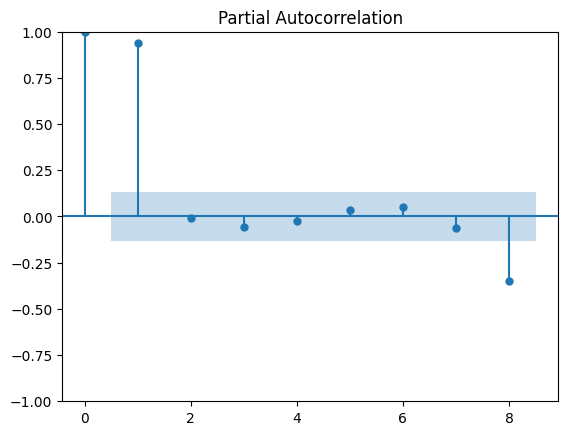

In [ ]:
plot_pacf(y_deseason, lags=8)

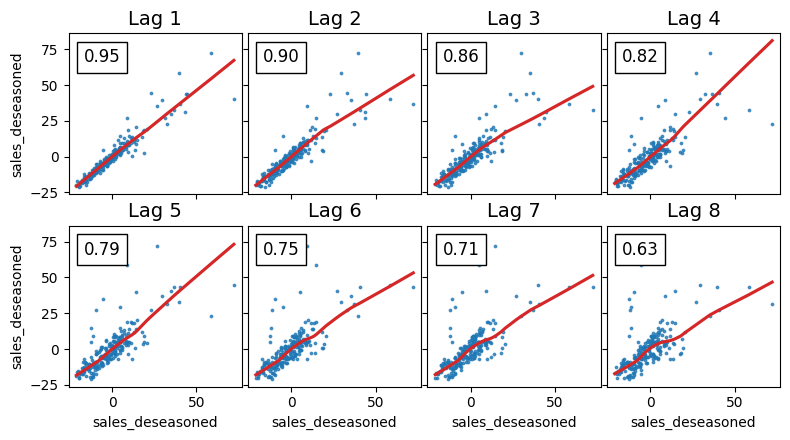

In [ ]:
plot_lags(y_deseason, lags=8, nrows=2)

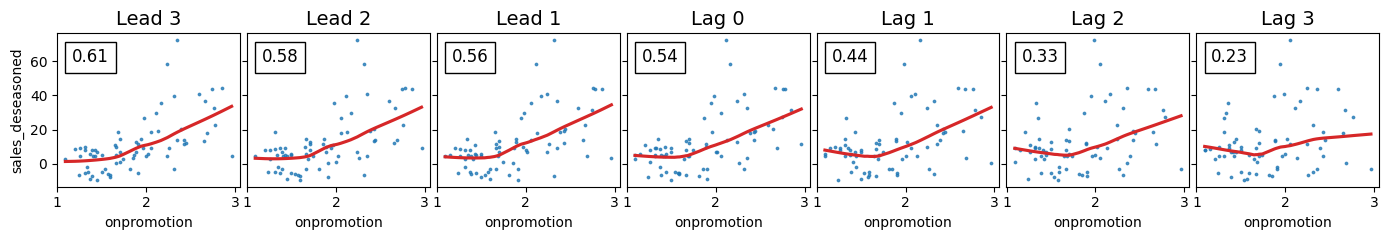

In [ ]:
onpromotion = supply_sales.loc[:, "onpromotion"].squeeze().rename("onpromotion")

plot_lags(x=onpromotion.loc[onpromotion > 1], y=y_deseason.loc[onpromotion > 1], lags=3, leads=3, nrows=1)

In [ ]:
family_sales = (
    stores_sales.groupby(["family", "date"])
    .mean()
    .unstack("family")
    .loc["2017"]
)

In [ ]:
class BoostedHybrid:
    def __init__(self, model_1, model_2):
        self.model_1 = model_1
        self.model_2 = model_2
        self.y_columns = None # to store column names from fit method
    def fit(self, X_1, X_2, y):
        self.model_1.fit(X_1, y)
        y_fit = pd.DataFrame(self.model_1.predict(X_1),
                             index=X_1.index, columns=y.columns)

        y_resid = y - y_fit
        y_resid = y_resid.stack().squeeze()

        self.model_2.fit(X_2, y_resid)
        self.y_columns = y.columns
    def predict(self, X_1, X_2):
        y_pred = pd.DataFrame(
            self.model_1.predict(X_1),
            index=X_1.index, columns=self.y_columns
        )
        y_pred = y_pred.stack().squeeze()
        y_pred += self.model_2.predict(X_2)
        return y_pred.unstack()

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
y = family_sales.loc[:, "sales"]
dp = DeterministicProcess(index=y.index, order=1)
X_1 = dp.in_sample()
X_2 = family_sales.drop("sales", axis=1).stack()
le = LabelEncoder()
X_2 = X_2.reset_index("family")
X_2["family"] = le.fit_transform(X_2["family"])
X_2["day"] = X_2.index.day

In [ ]:
from xgboost import XGBRegressor

notice that the dataframe passed to XGBRegressor does not need extrapolation for future values while that passed to LinearRegressor is a time dummy that keeps increasing hence will require extrapolation.

In [ ]:
model = BoostedHybrid(LinearRegression(), XGBRegressor())
model.fit(X_1, X_2, y)
y_pred = model.predict(X_1, X_2).clip(0.0)

In [ ]:
# Plotting some of the predictions.

y_train, y_valid = y[:"2017-07-01"], y["2017-07-02":]
X1_train, X1_valid = X_1[: "2017-07-01"], X_1["2017-07-02" :]
X2_train, X2_valid = X_2.loc[:"2017-07-01"], X_2.loc["2017-07-02":]

# Some of the algorithms above do best with certain kinds of
# preprocessing on the features (like standardization), but this is
# just a demo.
model.fit(X1_train, X2_train, y_train)
y_fit = model.predict(X1_train, X2_train).clip(0.0)
y_pred = model.predict(X1_valid, X2_valid).clip(0.0)

families = y.columns[0:6]
axs = y.loc(axis=1)[families].plot(
    subplots=True, sharex=True, figsize=(11, 9), **plot_params, alpha=0.5,
)
_ = y_fit.loc(axis=1)[families].plot(subplots=True, sharex=True, color='C0', ax=axs)
_ = y_pred.loc(axis=1)[families].plot(subplots=True, sharex=True, color='C3', ax=axs)
for ax, family in zip(axs, families):
    ax.legend([])
    ax.set_ylabel(family)

C:\Users\USER\AppData\Local\Temp\ipykernel_12840\2926216328.py:16: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  _ = y_fit.loc(axis=1)[families].plot(subplots=True, sharex=True, color='C0', ax=axs)
C:\Users\USER\AppData\Local\Temp\ipykernel_12840\2926216328.py:17: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  _ = y_pred.loc(axis=1)[families].plot(subplots=True, sharex=True, color='C3', ax=axs)
